# Malaria Classification Task (Infected or UnInfected)

<p> Colored Picture usually have 3 channels - Red, Blue and Green. Each pixel is made of a combination of these 3 channels. 
So our tensor for a colored picture will be (H,W,3): 3 is for 3 channels. A gray scale image has only 1 channel, therefore we have (H,W,1)</p>


<p>(Black = 0) --- (White = 255)</p>
<p>After Normalization, (Black = 0) --- (White = 1)</p>

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf # type: ignore
import tensorflow_datasets as tfds # type: ignore
import sklearn 
from sklearn.metrics import confusion_matrix, roc_curve
import seaborn as sns

# MODELS
Model = tf.keras.Model

#LAYERS
Input = tf.keras.layers.Input
Normalization = tf.keras.layers.Normalization
Dense = tf.keras.layers.Dense
InputLayer = tf.keras.layers.InputLayer
Conv2D = tf.keras.layers.Conv2D
MaxPool2D = tf.keras.layers.MaxPool2D
Flatten = tf.keras.layers.Flatten # Flatten is a function so you don't need a parantheses at the end.
BatchNormalization = tf.keras.layers.BatchNormalization
Layer = tf.keras.layers.Layer


#LOSSES
bce = tf.keras.losses.BinaryCrossentropy() # To instantiate a class you need to build an object which can only be done by including a parantheses at the end. 

# OPTIMIZER
Adam = tf.keras.optimizers.Adam

# METRICS
BinaryAccuracy = tf.keras.metrics.BinaryAccuracy # For a Binary Classification Problem
FalsePositives = tf.keras.metrics.FalsePositives
FalseNegatives = tf.keras.metrics.FalseNegatives
TruePositives = tf.keras.metrics.TruePositives
TrueNegatives = tf.keras.metrics.TrueNegatives
Precision = tf.keras.metrics.Precision
Recall = tf.keras.metrics.Recall
AUC = tf.keras.metrics.AUC

# Callbacks
Callback = tf.keras.callbacks.Callback
CSVLogger = tf.keras.callbacks.CSVLogger



In [2]:
dataset, dataset_info = tfds.load('malaria', with_info=True, as_supervised = True, shuffle_files=True, split=['train']) # tfds_load returns the dataset and dataset_info | 'with_info=True' gives the dataset_info
# as_supervised -> if True returns a dataset with a 2 tuple structure (input, label)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/incomplete.4EW4O0_1.0.0/malaria-train.tfrecord-[0-9][0-9][0-9][0-9…

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.


In [3]:
dataset # this is a list with 1 element, so only select dataset[0]

[<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>]

In [ ]:
dataset_info

tfds.core.DatasetInfo(
    name='malaria',
    full_name='malaria/1.0.0',
    description="""
    The Malaria dataset contains a total of 27,558 cell images with equal instances
    of parasitized and uninfected cells from the thin blood smear slide images of
    segmented cells.
    """,
    homepage='https://lhncbc.nlm.nih.gov/publication/pub9932',
    data_dir='/root/tensorflow_datasets/malaria/1.0.0',
    file_format=tfrecord,
    download_size=337.08 MiB,
    dataset_size=317.62 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=27558, num_shards=4>,
    },
    citation="""@article{rajaraman2018pre,
      title={Pre-trained convolutional neural networks as feature extractors toward
      improved malaria parasit

In [5]:
for data in dataset[0].take(2):
    print(data)

(<tf.Tensor: shape=(145, 148, 3), dtype=uint8, numpy=
array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)>, <tf.Tensor: shape=(), dtype=int64, numpy=1>)
(<tf.Tensor: shape=(151, 115, 3), dtype=uint8, numpy=
array([[[0, 0, 0],
        [0, 0, 0],
       

### Creating the Train, Test, Validation Datasets

In [ ]:
def splits(dataset, TRAIN_RATIO, VAL_RATIO, TEST_RATIO):
    DATASET_SIZE = len(dataset)

    # 1. Take the first 60% for training
    train_dataset = dataset.take(int(TRAIN_RATIO * DATASET_SIZE)) 

    # 2. Skip that 60% to look at the remaining 40% pool
    remaining_dataset = dataset.skip(int(TRAIN_RATIO * DATASET_SIZE))

    # 3. Take the first 20% of the total size from the remaining pool
    val_dataset = remaining_dataset.take(int(VAL_RATIO * DATASET_SIZE)) 

    # 4. Skip past the validation data to get the 5% and leave out 15% of the data
    test_pool = remaining_dataset.skip(int(TEST_RATIO * DATASET_SIZE))
    test_dataset = test_pool.take(int(TEST_RATIO * DATASET_SIZE))

    return train_dataset, val_dataset, test_dataset



In [7]:
TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.05

# dataset = tf.data.Dataset.range(10)

train_dataset, val_dataset, test_dataset = splits(dataset[0], TRAIN_RATIO, VAL_RATIO, TEST_RATIO)


print('Train Dataset\n', list(train_dataset.take(1).as_numpy_iterator()),'Val Dataset\n', list(val_dataset.take(1).as_numpy_iterator()),'Test Dataset\n', list(test_dataset.take(1).as_numpy_iterator()))

Train Dataset
 [(array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8), np.int64(1))] Val Dataset
 [(array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
     

In [8]:
for image, label in train_dataset.take(16):
    print("Image Matrix Shape:", image.shape) 
    print("Label Value:", label.numpy())

Image Matrix Shape: (103, 103, 3)
Label Value: 0
Image Matrix Shape: (115, 157, 3)
Label Value: 0
Image Matrix Shape: (136, 127, 3)
Label Value: 0
Image Matrix Shape: (166, 139, 3)
Label Value: 0
Image Matrix Shape: (148, 133, 3)
Label Value: 0
Image Matrix Shape: (112, 106, 3)
Label Value: 1
Image Matrix Shape: (106, 112, 3)
Label Value: 1
Image Matrix Shape: (124, 130, 3)
Label Value: 1
Image Matrix Shape: (124, 127, 3)
Label Value: 0
Image Matrix Shape: (142, 136, 3)
Label Value: 1
Image Matrix Shape: (163, 127, 3)
Label Value: 0
Image Matrix Shape: (109, 115, 3)
Label Value: 0
Image Matrix Shape: (157, 136, 3)
Label Value: 1
Image Matrix Shape: (124, 142, 3)
Label Value: 0
Image Matrix Shape: (133, 154, 3)
Label Value: 1
Image Matrix Shape: (124, 115, 3)
Label Value: 1


# Data Visualization

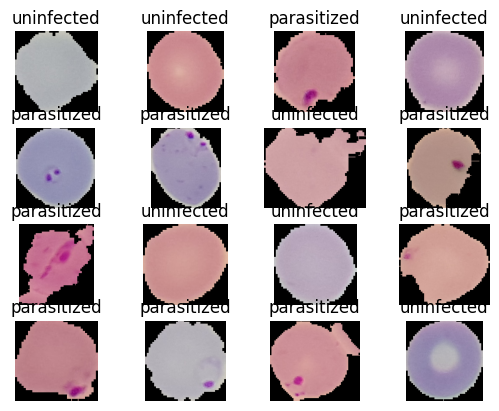

In [9]:
for i, (image, label) in enumerate(train_dataset.take(16)): # when using .take(), it goes from 1 - 16, hence the 'i+1'
    ax = plt.subplot(4,4, i+1) #(4,4) because we have 16 images
    plt.imshow(image)
    plt.title(dataset_info.features['label'].int2str(label))
    plt.axis('off')

In [ ]:
dataset_info.features['label'].int2str(0) # our label of 0 means that it is parasitized

'parasitized'

In [11]:
dataset_info.features['label'].int2str(1) # our label of 1 means that it is uninfected

'uninfected'

# Data Pre - Processing

##### Image Resizing -> Converting each image to 224,224 resolution

##### Standardization or Normalization

In [12]:
IM_SIZE = 224
def resize_rescale(image, label):
    return tf.image.resize(image,(IM_SIZE, IM_SIZE))/255.0, label
# We are dividing by 255 to rescale

In [13]:
train_dataset = train_dataset.map(resize_rescale)
val_dataset = val_dataset.map(resize_rescale)
test_dataset = test_dataset.map(resize_rescale)

In [14]:
for image, label in train_dataset.take(1):
    print(image, label)
# Image is resized

tf.Tensor(
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]], shape=(224, 224, 3), dtype=float32) tf.Tensor(1, shape=(), dtype=int64)


## Shuffling the dataset

In [15]:
train_dataset = train_dataset.shuffle(buffer_size=8, reshuffle_each_iteration=True).batch(32).prefetch(tf.data.AUTOTUNE)

# Don't reshuffle val_dataset, so no 'reshuffle_each_iteration=True'
val_dataset = val_dataset.shuffle(buffer_size=8).batch(32).prefetch(tf.data.AUTOTUNE)

# Don't do anything with the test_dataset

In [16]:
print(train_dataset,'\n', val_dataset)
print(f'Length of training Dataset: {len(train_dataset) * 32}')
print(f'Length of Validation Dataset: {len(val_dataset) * 32}')
print(f'Length of Test Dataset: {len(test_dataset)}')

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))> 
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
Length of training Dataset: 16544
Length of Validation Dataset: 5536
Length of Test Dataset: 1377


# Model Creation

### Sequential API

In [17]:
# LeNet Architecture
# The Models weights, are the filters that we learn
lenet_model = tf.keras.Sequential([
                            InputLayer(shape = (IM_SIZE, IM_SIZE,3)), 
                                   
                            Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Flatten(), 

                            Dense(100, activation='relu'),
                            BatchNormalization(),

                            Dense(10, activation='relu'),
                            BatchNormalization(),

                            Dense(1, activation='sigmoid')
                            ]) 

### Functional API

In [18]:
# PUTTING ALL THE FEATURE EXTRACTOR LAYER INTO 'feature_extractor_model'
func_input = Input(shape = (IM_SIZE, IM_SIZE,3), name = 'Input Image')

x = Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu', name = '1st Convolution Layer')(func_input)
x = BatchNormalization(name = '1st Normalization Layer')(x) 
x = MaxPool2D(pool_size= 2, strides=2, name = '1st Pooling Layer')(x)
x = Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu', name = '2nd Convolution Layer')(x)
x = BatchNormalization(name = '2nd Normalization Layer')(x)

output = MaxPool2D(pool_size= 2, strides=2, name = 'output')(x)

feature_extractor_model = Model(func_input, output, name = 'Feature_Extractor')
feature_extractor_model.summary()

Model: "Feature_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1st Convolution Layer (Conv2D)  │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1st Normalization Layer         │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1st Pooling Layer               │ (None, 111, 111, 6)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2nd Convolution Layer (Conv2D)  │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2nd Normalization Layer         │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (MaxPooling2D)           │ (None, 54, 54, 16)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,136 (4.44 KB)

 Trainable params: 1,092 (4.27 KB)

 Non-trainable params: 44 (176.00 B)

## Adding the Feature Extractor Model to the Classification Layers

In [19]:
func_input = Input(shape = (IM_SIZE, IM_SIZE,3), name = 'Input Image')

x = feature_extractor_model(func_input)


# Classification Layers
x = Flatten()(x) 

x = Dense(100, activation='relu')(x)
x = BatchNormalization()(x)

x = Dense(10, activation='relu')(x)
x = BatchNormalization()(x)

func_output = Dense(1, activation='sigmoid')(x)


# Need to mention that 'lenet_model_func' is a MODEL with 'func_input' and 'func_output'
lenet_model_func = Model(func_input, func_output, name = 'Lenet_Model')
lenet_model_func.summary()


Model: "Lenet_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Feature_Extractor (Functional)  │ (None, 54, 54, 16)     │         1,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

# Feature Extractor - Sequential Model

In [20]:
feature_extractor_seq_model = tf.keras.Sequential([
                            InputLayer(shape = (IM_SIZE, IM_SIZE,3)), 
                                   
                            Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2)])

x = feature_extractor_seq_model(func_input)


# Classification Layers
x = Flatten()(x) 

x = Dense(100, activation='relu')(x)
x = BatchNormalization()(x)

x = Dense(10, activation='relu')(x)
x = BatchNormalization()(x)

func_output = Dense(1, activation='sigmoid')(x)

lenet_model_func = Model(func_input, func_output, name = 'Lenet_Model')
lenet_model_func.summary()

Model: "Lenet_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 54, 54, 16)     │         1,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

In [21]:
# tf.keras.utils.plot_model(lenet_model, to_file='model.png', show_shapes=True)

In [22]:
'''lenet_model = tf.keras.Sequential([
                            InputLayer(shape = (IM_SIZE, IM_SIZE,3)), 
                                   
                            Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Flatten(), 

                            Dense(100, activation='relu'),
                            BatchNormalization(),

                            Dense(10, activation='relu'),
                            BatchNormalization(),

                            Dense(1, activation='sigmoid')
                            ]) '''
lenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

# Model SubClassing

In [23]:
class FeatureExtractor(Layer): # FeatureExtractor inherits from Layer
    def __init__(self, filters, kernel_size, strides, padding, activation, pool_size):
        super(FeatureExtractor, self).__init__() # This line reaches up to the parent Keras Layer class and boots up its internal initialization configuration.
        '''A native Keras layer has a ton of invisible, complex machinery required to track weight gradients and shape states.
           If you omit this line, your custom layer's setup will overwrite the core Keras setup, completely breaking the layer. Running super().__init__()
           ensures that Keras sets up its vital internal plumbing before you start adding your custom layers underneath it.'''
        


        # All the layers are being DEFINED here
        
        self.conv_1 = Conv2D(filters = filters, kernel_size = kernel_size, strides = strides, padding = padding, activation = activation)
        # we are equating filters = filters because we don't want to mix up the argument values here and how it is defined in the documentation
        self.batch_1 = BatchNormalization()
        self.pool_1 = MaxPool2D(pool_size = pool_size, strides = 2 * strides)

        self.conv_2 = Conv2D(filters = filters * 2, kernel_size = kernel_size, strides = strides, padding = padding, activation = activation)
        self.batch_2 = BatchNormalization()
        self.pool_2 = MaxPool2D(pool_size = pool_size, strides = 2 * strides)


    def call(self, x, training = False): 
        x = self.conv_1(x)
        x = self.batch_1(x)
        x = self.pool_1(x)

        x = self.conv_2(x)
        x = self.batch_2(x)
        x = self.pool_2(x)

        return x
        

feature_sub_classed = FeatureExtractor(8, 3, 1, 'valid', 'relu', 2)

In [24]:
func_input = Input(shape = (IM_SIZE, IM_SIZE,3), name = 'Input Image')

x = feature_sub_classed(func_input) 
# When you pass func_input into feature_sub_classed(...), 
# Keras automatically jumps inside your custom class and runs the 'call' method under the hood.

x = Flatten()(x) 

x = Dense(100, activation='relu')(x)
x = BatchNormalization()(x)

x = Dense(10, activation='relu')(x)
x = BatchNormalization()(x)

func_output = Dense(1, activation='sigmoid')(x)

lenet_model_func = Model(func_input, func_output, name = 'Lenet_Model: Feature Subclassing')
lenet_model_func.summary()

Model: "Lenet_Model: Feature Subclassing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_extractor               │ (None, 54, 54, 16)     │         1,488 │
│ (FeatureExtractor)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,649 (17.81 MB)

 Trainable params: 4,668,381 (17.81 MB)

 Non-trainable params: 268 (1.05 KB)

In [25]:
# Adding the Classification layer to make the whole LeNet Model

class LenetModel(Model):
  def __init__(self):
    super(LenetModel, self).__init__()

    self.feature_extractor = FeatureExtractor(8, 3, 1, "valid", "relu", 2)

    self.flatten = Flatten()

    self.dense_1 = Dense(100, activation = "relu")
    self.batch_1 = BatchNormalization()

    self.dense_2 = Dense(10, activation = "relu")
    self.batch_2 = BatchNormalization()

    self.dense_3 = Dense(1, activation = "sigmoid") # parameter 1: number of output units
    
  def call(self, x, training = False):

    x = self.feature_extractor(x)
    x = self.flatten(x)
    x = self.dense_1(x)
    x = self.batch_1(x)
    x = self.dense_2(x)
    x = self.batch_2(x)
    x = self.dense_3(x)

    return x





# Final LeNet Model using Feature Extractor + Classification Layer 
lenet_sub_classed = LenetModel()
lenet_sub_classed(tf.zeros([1,224,224,3]))
lenet_sub_classed.summary()

Model: "lenet_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_extractor_1             │ ?                      │         1,488 │
│ (FeatureExtractor)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (1, 46656)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (1, 100)               │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (1, 100)               │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (1, 10)                │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (1, 10)                │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (1, 1)                 │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,649 (17.81 MB)

 Trainable params: 4,668,381 (17.81 MB)

 Non-trainable params: 268 (1.05 KB)

# Custom Layers

In [26]:
# Instead of relying on tf.keras.layers.Dense, we are manually implementing the foundational linear algebra equation of deep learning
class NeuralearnDense(Layer): # Making the custom DENSE Layer
    def __init__(self, output_units, activation):
        super(NeuralearnDense, self).__init__()
        self.output_units = output_units # gives the number of columns
        self.activation = activation
    
    def build(self, input_features_shape): #Important '9:19:05'                                     INPUT: (Batch Size, Features), W: (Features,1), Bias: (Batch Size,1)
        #                                                                                           So Y = INPUT * W + B for the Dense Layer
                                        #      number of rows        number of columns
                                        #            |                      |
                                        #            v                      v
        self.w = self.add_weight(shape = (input_features_shape[-1], self.output_units), initializer='random_normal', trainable=True) # NEED TO GET THE SHAPES RIGHT 
        # random normal weight initializer
        self.b = self.add_weight(shape = (self.output_units, ), initializer='random_normal', trainable=True)

    def call(self, input_features): # This handles the actual forward pass math whenever data flows through the layer.

        pre_output = tf.matmul(input_features, self.w) + self.b # IMPORTANT: THE FORMULA FOR THE DENSE LAYER

        if (self.activation == 'relu'):
            return tf.nn.relu(pre_output)
        elif (self.activation == 'sigmoid'):
            return tf.math.sigmoid(pre_output)
        else:
            pre_output

In [27]:
# Using our custom DENSE LAYER
lenet_model_custom_dense = tf.keras.Sequential([
                            InputLayer(shape = (IM_SIZE, IM_SIZE,3)), 
                                   
                            Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Flatten(), 

                            NeuralearnDense(100, activation='relu'),
                            BatchNormalization(),

                            NeuralearnDense(10, activation='relu'),
                            BatchNormalization(),

                            NeuralearnDense(1, activation='sigmoid')
                            ]) 

lenet_model_custom_dense.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neuralearn_dense                │ (None, 100)            │     4,665,700 │
│ (NeuralearnDense)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neuralearn_dense_1              │ (None, 10)             │         1,010 │
│ (NeuralearnDense)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neuralearn_dense_2              │ (None, 1)              │            11 │
│ (NeuralearnDense)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

# Error Sanctioning -> Binary Cross Entropy Loss

In [28]:
y_true = [0,1,0,0] # hello ok
y_pred = [0.6, 0.51, 0.94, 1]
bce(y_true, y_pred) # use from_logits = True when the predictions are above 1 and lesser than 0.

<tf.Tensor: shape=(), dtype=float32, numpy=5.086357593536377>

### Metrics - Precision, Recall and Accuracy

In [51]:
metrics = [TruePositives(name='tp'), FalsePositives(name = 'fp'), TrueNegatives(name = 'tn'), FalseNegatives(name = 'fn'),
            BinaryAccuracy(name='Binary Accuracy'), Precision(name = 'precision'), Recall(name = 'recall'), AUC(name = 'auc')]

In [48]:
lenet_model.compile(optimizer= Adam(learning_rate = 0.01), loss = 'bce', metrics = metrics) # or could addmetrics = [RootMeanSquaredError()]

In [31]:
# lenet_model_func.compile(optimizer= Adam(learning_rate = 0.01), loss = 'bce', metrics = ['accuracy']) #metrics = [RootMeanSquaredError()]

# Model Training

# CallBacks

Callbacks are special tools that let you sneak a peek inside your neural network while it is actively training

In [91]:
class LossCallback(Callback):
    def on_epoch_end(self, epoch, logs):
        print(f"\nEpoch Number {epoch + 1} has a loss of {logs['loss']}")

    def on_batch_end(self, batch, logs):
        print(f"\nBatch Number {batch + 1} has a loss of {logs}")


# CSVLogger

In [92]:
csv_callback = tf.keras.callbacks.CSVLogger(
    'logs.csv', separator=',', append=False
)

In [93]:
History = lenet_model.fit(train_dataset, validation_data=val_dataset, epochs=2, verbose=1, callbacks=[csv_callback]) # Can include 'LossCallback()' in the callbacks list 

# History Object here is a callback

Epoch 1/2
517/517 ━━━━━━━━━━━━━━━━━━━━ 33s 63ms/step - Binary Accuracy: 0.9742 - auc: 0.9962 - fn: 202.0000 - fp: 225.0000 - loss: 0.0707 - precision: 0.9728 - recall: 0.9755 - tn: 8050.0000 - tp: 8057.0000 - val_Binary Accuracy: 0.9042 - val_auc: 0.9574 - val_fn: 263.0000 - val_fp: 265.0000 - val_loss: 0.3438 - val_precision: 0.9042 - val_recall: 0.9048 - val_tn: 2483.0000 - val_tp: 2500.0000
Epoch 2/2
517/517 ━━━━━━━━━━━━━━━━━━━━ 32s 62ms/step - Binary Accuracy: 0.9760 - auc: 0.9969 - fn: 198.0000 - fp: 199.0000 - loss: 0.0661 - precision: 0.9759 - recall: 0.9760 - tn: 8072.0000 - tp: 8065.0000 - val_Binary Accuracy: 0.9310 - val_auc: 0.9607 - val_fn: 148.0000 - val_fp: 232.0000 - val_loss: 0.4107 - val_precision: 0.9185 - val_recall: 0.9465 - val_tn: 2515.0000 - val_tp: 2616.0000


In [85]:
# History2 = lenet_model_func.fit(train_dataset, validation_data=val_dataset, epochs=10, verbose=1) # Training the model made through the FUNCTIONAL API

In [34]:
print(History.history.keys())

dict_keys(['Binary Accuracy', 'auc', 'fn', 'fp', 'loss', 'precision', 'recall', 'tn', 'tp', 'val_Binary Accuracy', 'val_auc', 'val_fn', 'val_fp', 'val_loss', 'val_precision', 'val_recall', 'val_tn', 'val_tp'])


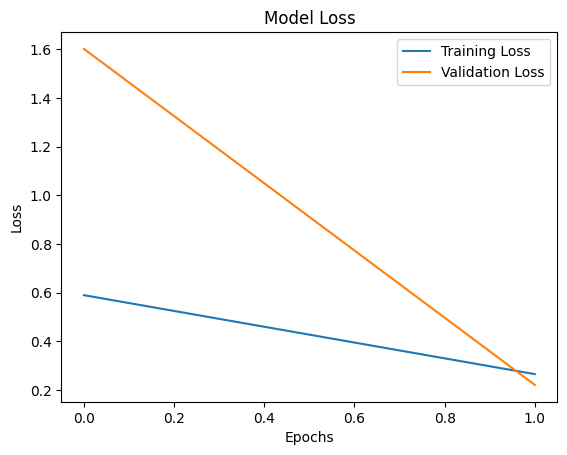

In [35]:
plt.plot(History.history['loss'], label='Training Loss') 
plt.plot(History.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend() # Needs to be in a list
plt.show()

# Model Evaluation and Testing

In [36]:
# list(test_dataset.as_numpy_iterator())

In [37]:
test_dataset = test_dataset.batch(1) # Have to do this because we need to keep into account the dimension of the test dataset as well while evaluating.
lenet_model.evaluate(test_dataset)

# We have a 64.5% accuracy

1377/1377 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - Binary Accuracy: 0.9201 - auc: 0.9663 - fn: 65.0000 - fp: 45.0000 - loss: 0.2312 - precision: 0.9327 - recall: 0.9057 - tn: 643.0000 - tp: 624.0000


[0.2312355637550354,
 624.0,
 45.0,
 643.0,
 65.0,
 0.9201161861419678,
 0.9327354431152344,
 0.9056603908538818,
 0.9663018584251404]

# Visualizing Confusion Matrix

In [ ]:
labels = []
inp = [] # input

for x,y in test_dataset.as_numpy_iterator():
    labels.append(y[0]) # we did y[0] to ge the number in the list which was like [array([1]), array([0])...]
    inp.append(x)

In [58]:
# labels = np.array([i[0] for i in labels])
print(labels)
print(len(labels))

[np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0)

In [ ]:
print(np.array(inp).shape)
print(np.array(inp)[:,0,...].shape) # Want to remove the 1st index dimension aka the '1', so we put a '0'. ':' is for selecting the 0th index, '0' is for not selecting the 1st index

(1377, 1, 224, 224, 3)
(1377, 224, 224, 3)


In [ ]:
predicted = lenet_model.predict(np.array(inp)[:,0,...])

44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
[0.02172172 0.0080144  0.99312025 ... 0.42330825 0.4653181  0.04919016]


In [61]:
print(predicted.shape)

# We want to make the predicted shape to be the same as the labels shape
print(f'Predicted Shape: {predicted[:,0].shape}')
print(f'Labels Shape: {len(labels)}')

print(predicted[:,0])

(1377, 1)
Predicted Shape: (1377,)
Labels Shape: 1377
[0.02172172 0.0080144  0.99312025 ... 0.42330825 0.4653181  0.04919016]


[[645  46]
 [ 67 619]]


Text(0.5, 36.72222222222221, 'Predicted')

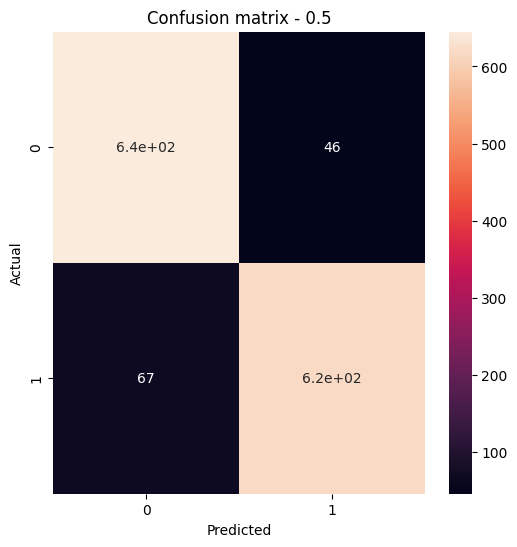

In [73]:
# MAKING THE CONFUSION MATRIX
threshold = 0.5
# If we reduce the threshold to a lower value, then most of our predictions are going to be positive, thereby reducing our false negatives
# Also pick thersholds such that our True Positives and True Negative don't get reduced

cm = confusion_matrix(labels, predicted > threshold) # all values great than threshold is uninfected
print(cm)
plt.figure(figsize=(6,6))

sns.heatmap(cm, annot=True,)
plt.title(f'Confusion matrix - {threshold}')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# tn: 643.0000 - tp: 624.0000
# fn: 65.0000 - fp: 45.0000

We want a low number for the FALSE NEGATIVES(FN), so in this case we want a high 'RECALL'

# ROC Curve


We can use this to choose the best threshold.

A point at the ROC plot is a threshold value for the TP rate and the FP rate.
Y axis - Recall [TP/(TP + FN)]

X axis - [FP/(FP+TN)]

Overall GOAL - FP is MINIMIZED and TP is MAXIMIZED

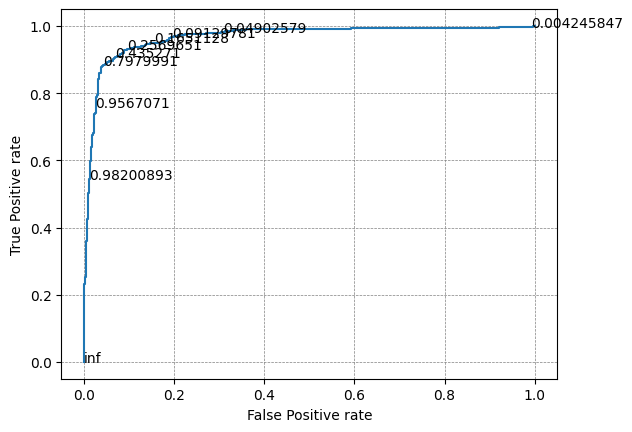

In [70]:
# If we reduce the threshold to a lower value, then most of our predictions are going to be positive, thereby reducing our false negatives
# Also pick thersholds such that our True Positives and True Negative don't get reduced

fp, tp, thresholds = roc_curve(labels, predicted)
plt.plot(fp, tp)
plt.xlabel("False Positive rate")
plt.ylabel("True Positive rate")
plt.grid(color='gray', linestyle='--', linewidth=0.5)

skip =  20 # skip 30 values and then plot it

for i in range(0, len(thresholds), skip):
  plt.text(fp[i], tp[i], thresholds[i]) # to show the thresholds

plt.show()

In [ ]:
def parasite_or_not(x):
    if (x < 0.5):
        return 'P'
    else:
        return 'U'

In [ ]:
parasite_or_not(lenet_model.predict(test_dataset.take(1))[0][0]) 

'''# lenet_model.predict(test_dataset.take(1)) outputs:
[
  [0.85], # Image 0 prediction
  [0.12], # Image 1 prediction
  [0.44], # Image 2 prediction
  ...
  [0.91]  # Image 32 prediction
]
TensorFlow models output predictions in a 2D batch format [[0.85], [0.12]]. The first [0] selects the specific image in the batch, and the second [0] extracts the raw probability number 
from inside that vector.'''

NameError: name 'lenet_model' is not defined

In [ ]:
for i,(image,label) in enumerate(test_dataset.take(9)):

    ax = plt.subplot(3,3, i+1)
    plt.imshow(image[0])
    plt.title(str(parasite_or_not(label.numpy()[0])) + ':' + str(parasite_or_not(lenet_model.predict(image)[0][0])))
    plt.axis('off')

NameError: name 'test_dataset' is not defined

# Saving to and Loading from Google Drive

In [ ]:
from google.colab import drive # type: ignore
drive.mount('/content/drive')

MessageError: Failed to issue request POST https://colab.research.google.com/tun/m/credentials-propagation/gpu-t4-s-kkb-usw4b2-371r393nplxzb?authtype=dfs_ephemeral&version=2&dryrun=false&propagate=true&record=false&authuser=0: Bad Request
Response body: 
<!DOCTYPE html>
<html lang=en>
  <meta charset=utf-8>
  <meta name=viewport content="initial-scale=1, minimum-scale=1, width=device-width">
  <title>Error 400 (Bad Request)!!1</title>
  <style>
    *{margin:0;padding:0}html,code{font:15px/22px arial,sans-serif}html{background:#fff;color:#222;padding:15px}body{margin:7% auto 0;max-width:390px;min-height:180px;padding:30px 0 15px}* > body{background:url(//www.google.com/images/errors/robot.png) 100% 5px no-repeat;padding-right:205px}p{margin:11px 0 22px;overflow:hidden}ins{color:#777;text-decoration:none}a img{border:0}@media screen and (max-width:772px){body{background:none;margin-top:0;max-width:none;padding-right:0}}#logo{background:url(//www.google.com/images/logos/errorpage/error_lo

In [ ]:
lenet_model.export('/content/drive/MyDrive/lenet_saved_directory')
drive_folder_path = '/content/drive/MyDrive/lenet_saved_directory'

# Load the directory as a specialized inference layer
lenet_loaded = tf.keras.layers.TFSMLayer(drive_folder_path, call_endpoint='serve')

print("Model loaded successfully from Google Drive!")

In [ ]:
lenet_model.save('/content/drive/MyDrive/lenet_malaria_saved_model.keras')
lenet_loaded = tf.keras.models.load_model('/content/drive/MyDrive/lenet_malaria_saved_model.keras')
lenet_loaded.summary()

In [ ]:
# Using the LOADED MODEL from google drive to do the predictions
for i,(image,label) in enumerate(test_dataset.take(9)):

    ax = plt.subplot(3,3, i+1)
    plt.imshow(image[0])
    plt.title(str(parasite_or_not(label.numpy()[0])) + ':' + str(parasite_or_not(lenet_loaded.predict(image)[0][0])))
    plt.axis('off')

In [ ]:
lenet_loaded.evaluate(test_dataset)

# Saving using the HDF5 method -> lightweight Model Saving Method

In [ ]:
# In a HDF5 format the configurations aren't stored, so you will have to compile the model again
lenet_model.save('/content/drive/MyDrive/lenet_malaria_model.h5')


In [ ]:
h5_model_path = '/content/drive/MyDrive/lenet_malaria_model.h5'
lenet_loaded_h5 = tf.keras.models.load_model(h5_model_path, compile=False) 
# If you only want to use the model for inference (making predictions) 
#and want to skip loading the optimizer, you can add compile=False to speed things up
# Setting compile=False tells Keras: "Just load the brain (weights and architecture). Do not waste time loading the training setup or rebuilding the optimizer."
lenet_loaded_h5.summary()

In [ ]:
# lenet_loaded_h5.evaluate(test_dataset) # In a HDF5 format the configurations aren't stored, so you will have to compile the model again

# ERROR GIVEN - You must call `compile()` before using the model.

#### Saving Just the Weights given that we already have the model's configurations

In [ ]:
# lenet_model.save_weights("weights/lenet_weights.weights.h5")

In [ ]:
# lenet_weights_model = lenet_model.load_weights("weights/lenet_weights")